C:\Users\veron\AppData\Local\Temp\ipykernel_19892\2509599104.py:32: DtypeWarning: Columns (106,107,228,230,243,245,247,249,251,252,260,262,264,266,268,269,277,279,281,283,285,286,294,300,302,303,311,313,371,373,374,383,385,386,395,396,397,398,399,407,408,409,410,411,416,418,419,420,421,422,423,428,430,431,432,433,435,440,441,442,443,444,445,446,447,448,450,451,452,453,454,459,460,462,463,464,465,466,470,472,474,475,476,477,484,486,487,488,489,490,496,498,499,501,502,508,510,511,513,730,735,737,755,756,761,762,763,777,779,781,782,788,791,799,801,803,805,808,814,817,825,827,829,1016,1024,1028,1033,1034,1040,1041,1042,1046,1048,1051,1052,1058,1059,1060,1064,1066,1069,1070,1076,1077,1078,1082,1084,1087,1094,1095,1096,1099,1100,1102,1105,1112,1113,1114,1115,1117,1118,1120,1123,1124,1130,1131,1132,1133,1134,1135,1136,1138,1141,1144,1145,1148,1149,1151,1152,1153,1156,1161,1162,1163,1166,1167,1169,1170,1171,1174,1177,1178,1179,1180,1181,1184,1185,1187,1188,1189,1195,1197,1198,1199,1202,1203,12

Total samples loaded: 24497


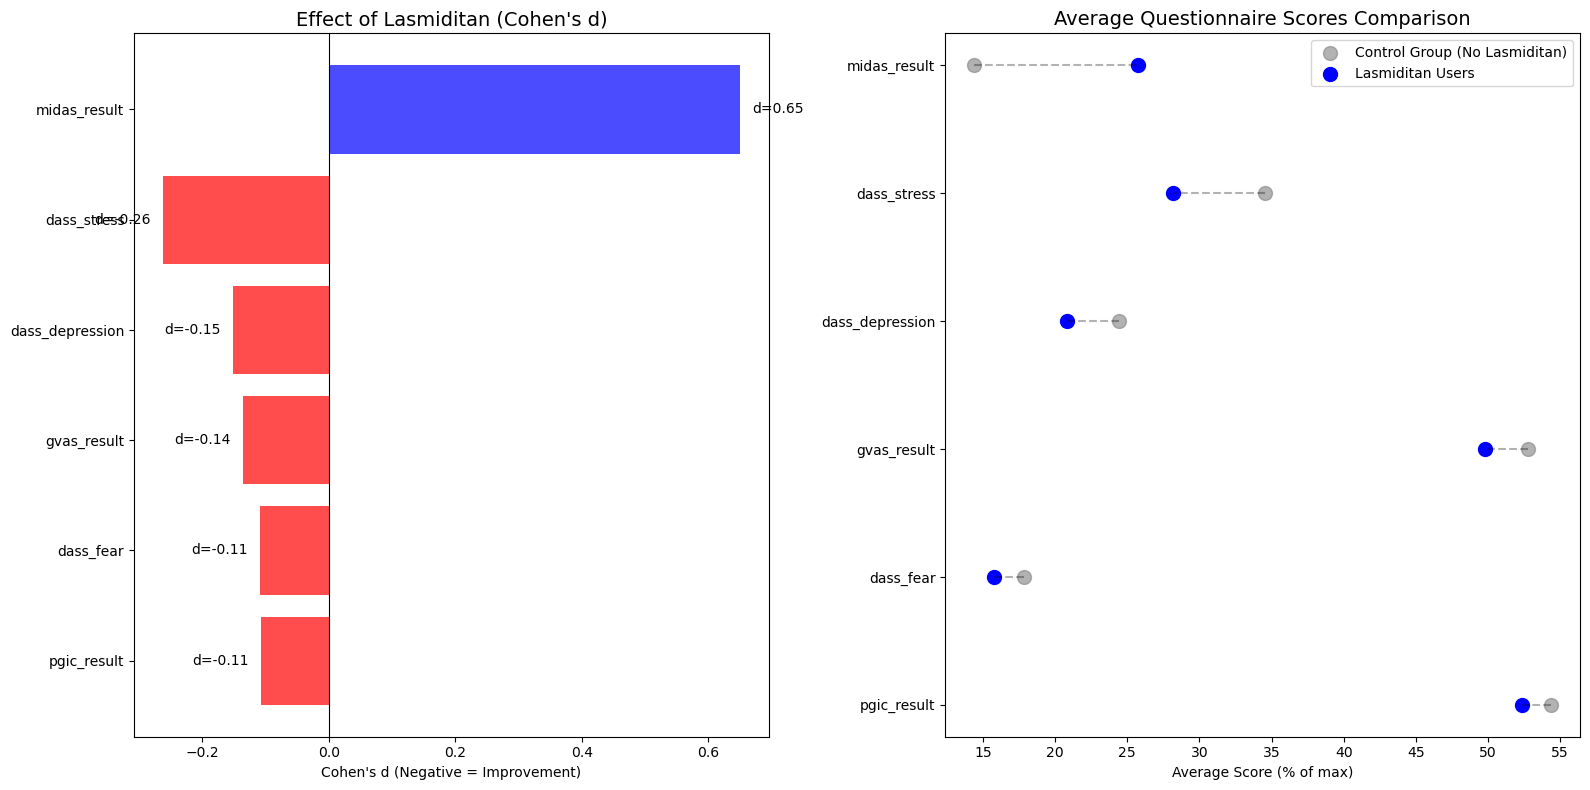

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import re
import textwrap
from scipy.stats import ttest_ind

# =========================================================
# CONFIG
# =========================================================
DATA_DIR = Path("./patienten-visiten")
csv_files = sorted(DATA_DIR.glob("Patients_V*.csv"))
MEDICATION_QUERY = "Lasmiditan"
score_bases = ["midas_result", "dass_depression", "dass_fear", "dass_stress", "gvas_result", "pgic_result"]

score_ranges = {
    "pgic_result": 7,
    "dass_depression": 21,  # Corrected from 24
    "dass_fear": 21,
    "dass_stress": 21,      # Corrected from 42
    "gvas_result": 100,
    "midas_result": 279     # Based on data max
}
pattern = rf"\b{re.escape(MEDICATION_QUERY)}"

# =========================================================
# DATA LOADING (LOAD ONCE)
# =========================================================
combined_data = []
for file in csv_files:
    df = pd.read_csv(file, sep=";")
    med_cols = [c for c in df.columns if c.startswith("acute_name_a")]
    if not med_cols: continue
    
    # Extract medication flag
    df['has_med'] = df[med_cols].astype(str).agg(" ".join, axis=1).str.contains(pattern, case=False, na=False)
    
    # Extract scores
    relevant_cols = ['has_med']
    for base in score_bases:
        cols = [c for c in df.columns if c.startswith(base)]
        if cols:
            df[f"score_{base}"] = df[cols].apply(lambda x: pd.to_numeric(x.astype(str).str.replace(',', '.'), errors="coerce")).mean(axis=1)
            relevant_cols.append(f"score_{base}")
    
    combined_data.append(df[relevant_cols])

data = pd.concat(combined_data, ignore_index=True)
print("Total samples loaded:", len(data))

# =========================================================
# ANALYSIS PER SCORE TYPE
# =========================================================
results = []
for base in score_bases:
    col = f"score_{base}"
    if col not in data.columns: continue
    
    tmp = data[['has_med', col]].dropna()
    med_s = tmp[tmp['has_med']][col]
    ctrl_s = tmp[~tmp['has_med']][col]
    
    if len(med_s) < 5 or len(ctrl_s) < 5: continue
    
    # Convert to percentage for normalized comparison
    max_range = score_ranges.get(base, 100)
    med_pct = (med_s / max_range) * 100
    ctrl_pct = (ctrl_s / max_range) * 100
    
    # Cohen's d
    pooled_std = np.sqrt(((len(med_pct)-1)*med_pct.var() + (len(ctrl_pct)-1)*ctrl_pct.var()) / (len(med_pct)+len(ctrl_pct)-2))
    d = (med_pct.mean() - ctrl_pct.mean()) / pooled_std if pooled_std != 0 else 0
    
    results.append({
        "questionnaire": base,
        "mean_med_pct": med_pct.mean(),
        "mean_ctrl_pct": ctrl_pct.mean(),
        "cohens_d": d,
        "n_med": len(med_s),
        "n_ctrl": len(ctrl_s)
    })

res = pd.DataFrame(results).sort_values("cohens_d", key=abs)
res["questionnaire_wrapped"] = res["questionnaire"].apply(lambda x: textwrap.fill(str(x), width=15))

# =========================================================
# IMPROVED PLOTS
# =========================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Plot 1: Cohen's d
colors = ['red' if x < 0 else 'blue' for x in res['cohens_d']]
bars = ax1.barh(res["questionnaire_wrapped"], res["cohens_d"], color=colors, alpha=0.7)
ax1.axvline(0, color="black", linewidth=0.8)
ax1.set_title(f"Effect of {MEDICATION_QUERY} (Cohen's d)", fontsize=14)
ax1.set_xlabel("Cohen's d (Negative = Improvement)")
for i, bar in enumerate(bars):
    val = res["cohens_d"].iloc[i]
    ha = 'left' if val >= 0 else 'right'
    offset = 0.02 if val >= 0 else -0.02
    ax1.text(val + offset, bar.get_y() + bar.get_height()/2, f'd={val:.2f}', va='center', ha=ha)

# Plot 2: Absolute Comparison
y = np.arange(len(res))
ax2.scatter(res["mean_ctrl_pct"], y, color='gray', label="Control Group (No Lasmiditan)", s=100, alpha=0.6)
ax2.scatter(res["mean_med_pct"], y, color='blue', label=f"{MEDICATION_QUERY} Users", s=100)
for i in range(len(res)):
    ax2.plot([res["mean_ctrl_pct"].iloc[i], res["mean_med_pct"].iloc[i]], [i, i], color='black', alpha=0.3, linestyle='--')
ax2.set_yticks(y)
ax2.set_yticklabels(res["questionnaire_wrapped"])
ax2.set_xlabel("Average Score (% of max)")
ax2.set_title("Average Questionnaire Scores Comparison", fontsize=14)
ax2.legend()

plt.tight_layout()
plt.show()

C:\Users\veron\AppData\Local\Temp\ipykernel_19892\3432615368.py:29: DtypeWarning: Columns (106,107,228,230,243,245,247,249,251,252,260,262,264,266,268,269,277,279,281,283,285,286,294,300,302,303,311,313,371,373,374,383,385,386,395,396,397,398,399,407,408,409,410,411,416,418,419,420,421,422,423,428,430,431,432,433,435,440,441,442,443,444,445,446,447,448,450,451,452,453,454,459,460,462,463,464,465,466,470,472,474,475,476,477,484,486,487,488,489,490,496,498,499,501,502,508,510,511,513,730,735,737,755,756,761,762,763,777,779,781,782,788,791,799,801,803,805,808,814,817,825,827,829,1016,1024,1028,1033,1034,1040,1041,1042,1046,1048,1051,1052,1058,1059,1060,1064,1066,1069,1070,1076,1077,1078,1082,1084,1087,1094,1095,1096,1099,1100,1102,1105,1112,1113,1114,1115,1117,1118,1120,1123,1124,1130,1131,1132,1133,1134,1135,1136,1138,1141,1144,1145,1148,1149,1151,1152,1153,1156,1161,1162,1163,1166,1167,1169,1170,1171,1174,1177,1178,1179,1180,1181,1184,1185,1187,1188,1189,1195,1197,1198,1199,1202,1203,12

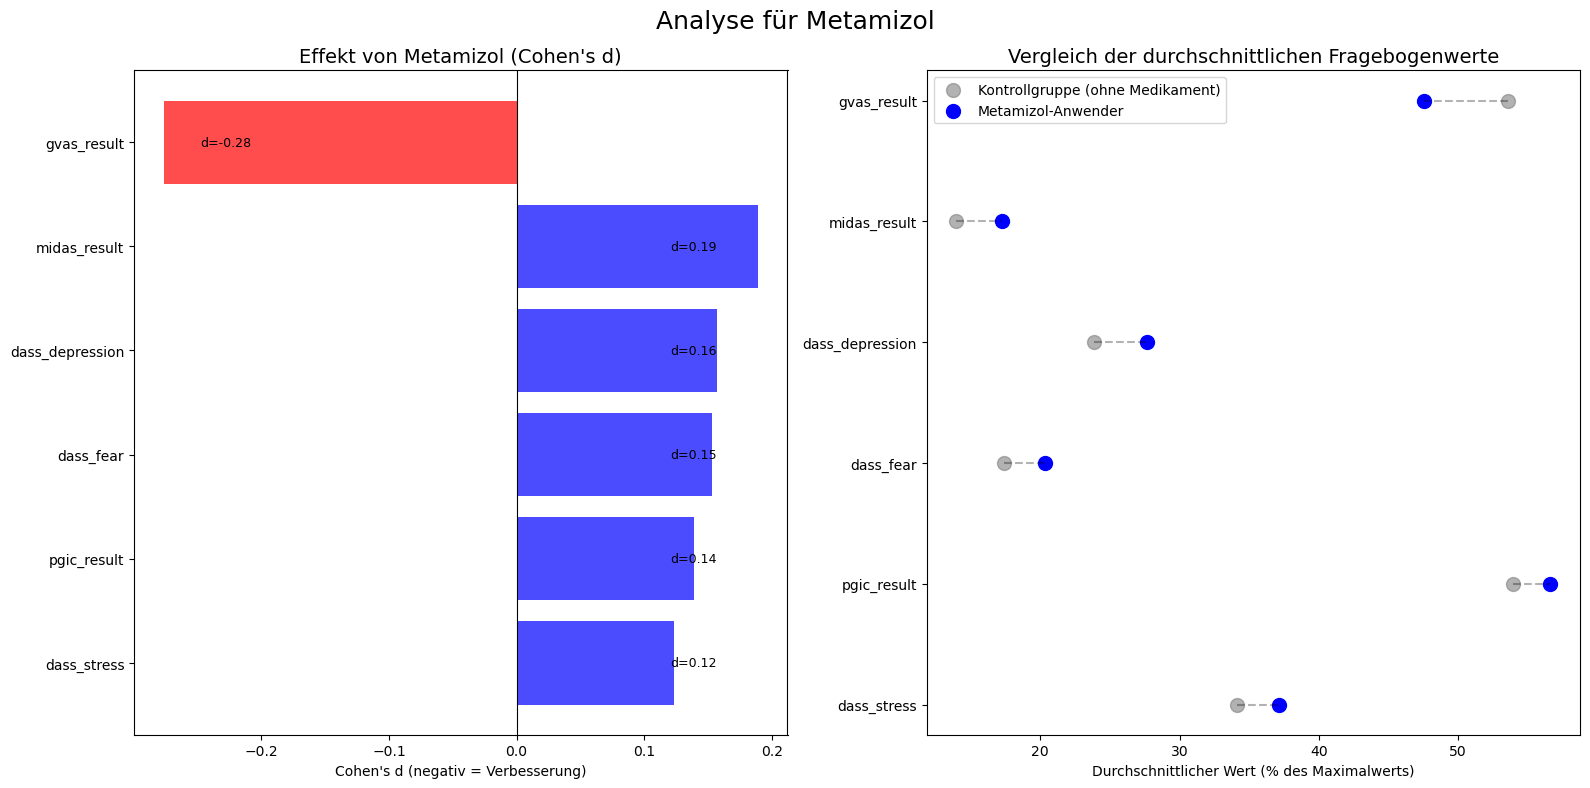

C:\Users\veron\AppData\Local\Temp\ipykernel_19892\3432615368.py:29: DtypeWarning: Columns (106,107,228,230,243,245,247,249,251,252,260,262,264,266,268,269,277,279,281,283,285,286,294,300,302,303,311,313,371,373,374,383,385,386,395,396,397,398,399,407,408,409,410,411,416,418,419,420,421,422,423,428,430,431,432,433,435,440,441,442,443,444,445,446,447,448,450,451,452,453,454,459,460,462,463,464,465,466,470,472,474,475,476,477,484,486,487,488,489,490,496,498,499,501,502,508,510,511,513,730,735,737,755,756,761,762,763,777,779,781,782,788,791,799,801,803,805,808,814,817,825,827,829,1016,1024,1028,1033,1034,1040,1041,1042,1046,1048,1051,1052,1058,1059,1060,1064,1066,1069,1070,1076,1077,1078,1082,1084,1087,1094,1095,1096,1099,1100,1102,1105,1112,1113,1114,1115,1117,1118,1120,1123,1124,1130,1131,1132,1133,1134,1135,1136,1138,1141,1144,1145,1148,1149,1151,1152,1153,1156,1161,1162,1163,1166,1167,1169,1170,1171,1174,1177,1178,1179,1180,1181,1184,1185,1187,1188,1189,1195,1197,1198,1199,1202,1203,12

Keine ausreichenden Daten für Spalt®Schmerztabletten.


C:\Users\veron\AppData\Local\Temp\ipykernel_19892\3432615368.py:29: DtypeWarning: Columns (106,107,228,230,243,245,247,249,251,252,260,262,264,266,268,269,277,279,281,283,285,286,294,300,302,303,311,313,371,373,374,383,385,386,395,396,397,398,399,407,408,409,410,411,416,418,419,420,421,422,423,428,430,431,432,433,435,440,441,442,443,444,445,446,447,448,450,451,452,453,454,459,460,462,463,464,465,466,470,472,474,475,476,477,484,486,487,488,489,490,496,498,499,501,502,508,510,511,513,730,735,737,755,756,761,762,763,777,779,781,782,788,791,799,801,803,805,808,814,817,825,827,829,1016,1024,1028,1033,1034,1040,1041,1042,1046,1048,1051,1052,1058,1059,1060,1064,1066,1069,1070,1076,1077,1078,1082,1084,1087,1094,1095,1096,1099,1100,1102,1105,1112,1113,1114,1115,1117,1118,1120,1123,1124,1130,1131,1132,1133,1134,1135,1136,1138,1141,1144,1145,1148,1149,1151,1152,1153,1156,1161,1162,1163,1166,1167,1169,1170,1171,1174,1177,1178,1179,1180,1181,1184,1185,1187,1188,1189,1195,1197,1198,1199,1202,1203,12

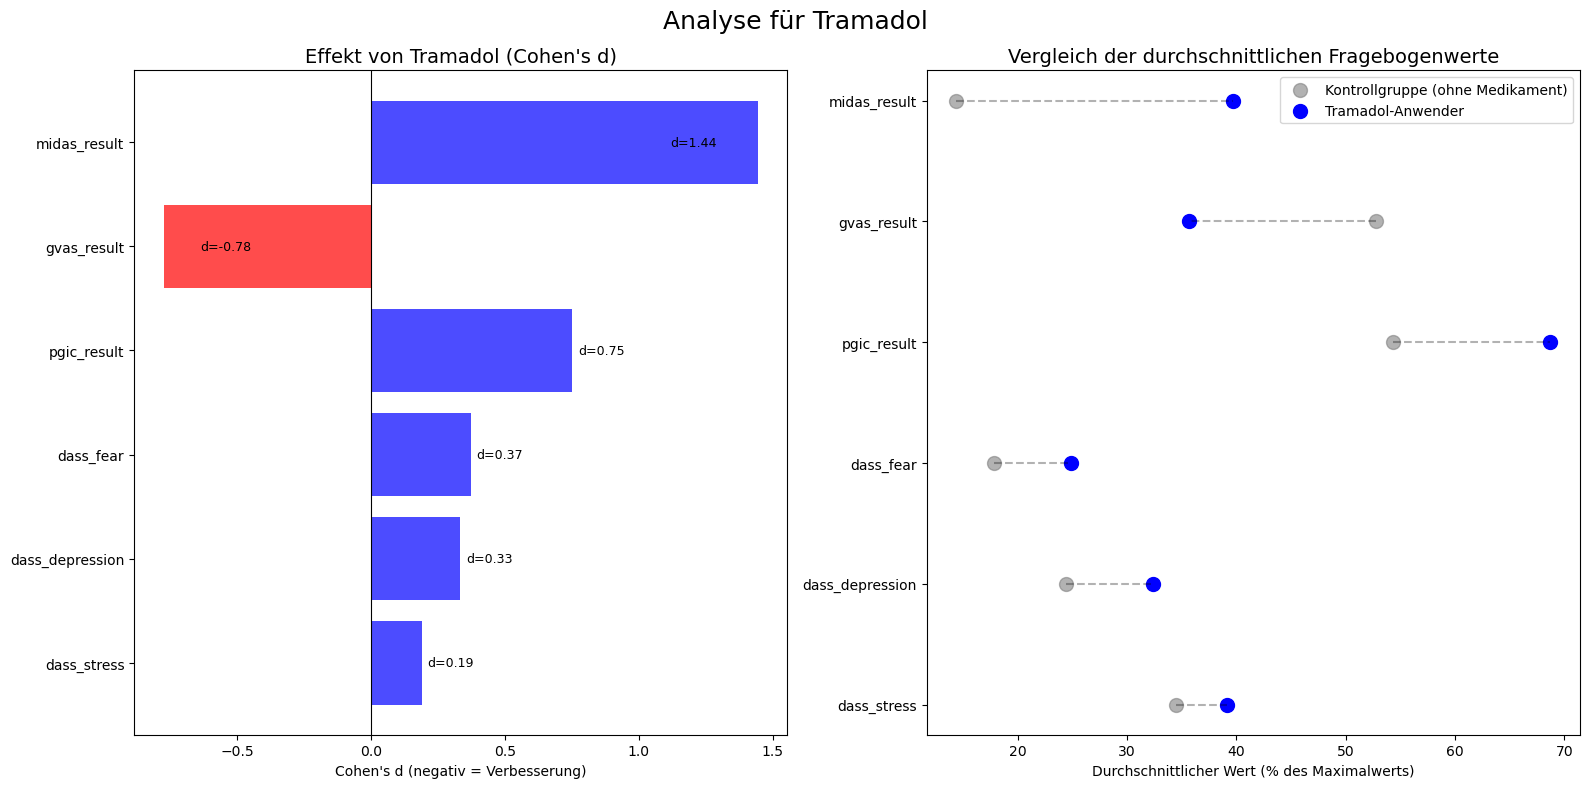

C:\Users\veron\AppData\Local\Temp\ipykernel_19892\3432615368.py:29: DtypeWarning: Columns (106,107,228,230,243,245,247,249,251,252,260,262,264,266,268,269,277,279,281,283,285,286,294,300,302,303,311,313,371,373,374,383,385,386,395,396,397,398,399,407,408,409,410,411,416,418,419,420,421,422,423,428,430,431,432,433,435,440,441,442,443,444,445,446,447,448,450,451,452,453,454,459,460,462,463,464,465,466,470,472,474,475,476,477,484,486,487,488,489,490,496,498,499,501,502,508,510,511,513,730,735,737,755,756,761,762,763,777,779,781,782,788,791,799,801,803,805,808,814,817,825,827,829,1016,1024,1028,1033,1034,1040,1041,1042,1046,1048,1051,1052,1058,1059,1060,1064,1066,1069,1070,1076,1077,1078,1082,1084,1087,1094,1095,1096,1099,1100,1102,1105,1112,1113,1114,1115,1117,1118,1120,1123,1124,1130,1131,1132,1133,1134,1135,1136,1138,1141,1144,1145,1148,1149,1151,1152,1153,1156,1161,1162,1163,1166,1167,1169,1170,1171,1174,1177,1178,1179,1180,1181,1184,1185,1187,1188,1189,1195,1197,1198,1199,1202,1203,12

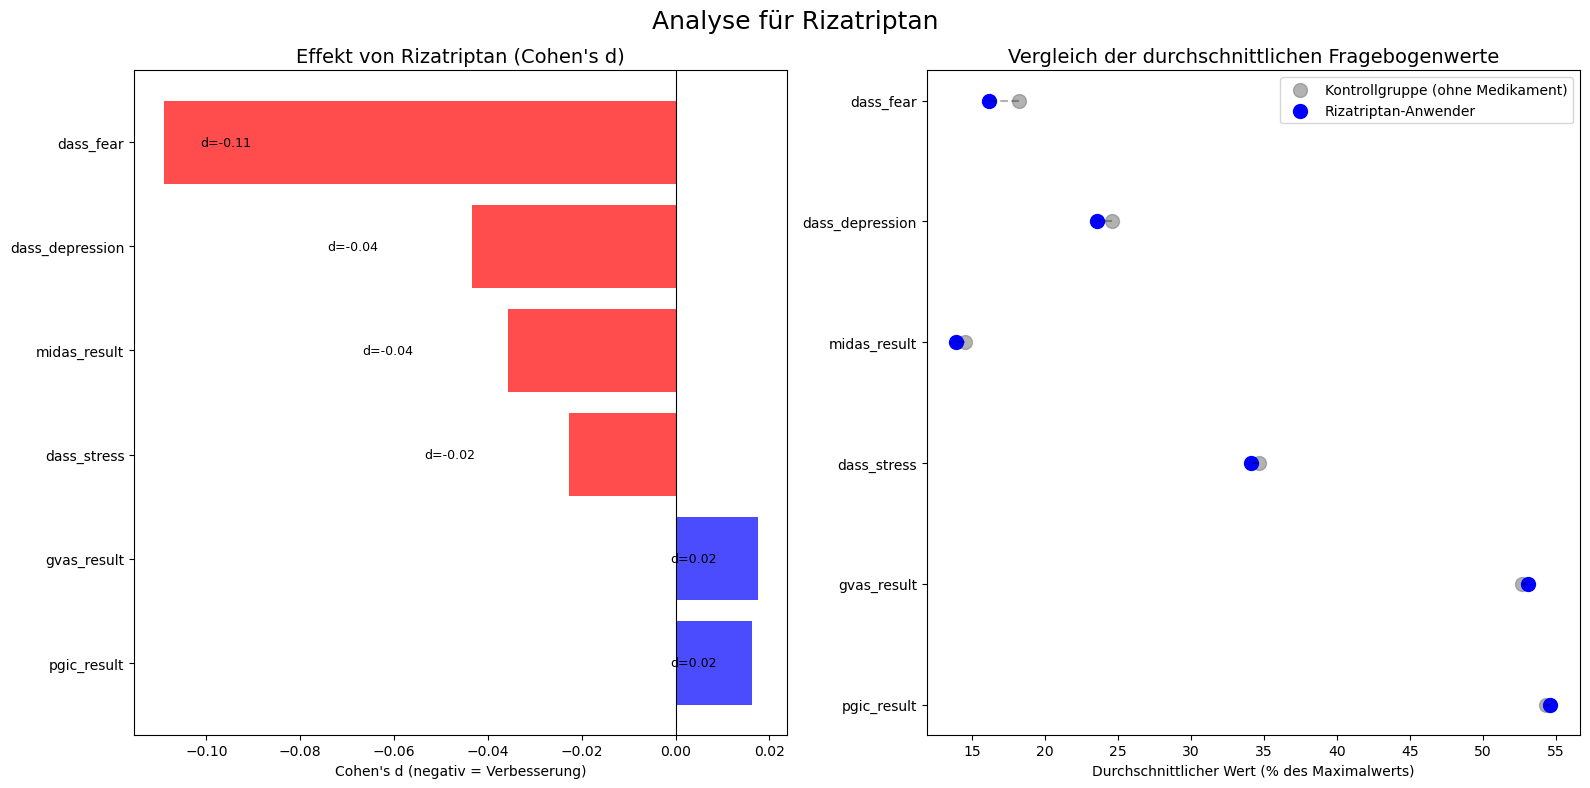

C:\Users\veron\AppData\Local\Temp\ipykernel_19892\3432615368.py:29: DtypeWarning: Columns (106,107,228,230,243,245,247,249,251,252,260,262,264,266,268,269,277,279,281,283,285,286,294,300,302,303,311,313,371,373,374,383,385,386,395,396,397,398,399,407,408,409,410,411,416,418,419,420,421,422,423,428,430,431,432,433,435,440,441,442,443,444,445,446,447,448,450,451,452,453,454,459,460,462,463,464,465,466,470,472,474,475,476,477,484,486,487,488,489,490,496,498,499,501,502,508,510,511,513,730,735,737,755,756,761,762,763,777,779,781,782,788,791,799,801,803,805,808,814,817,825,827,829,1016,1024,1028,1033,1034,1040,1041,1042,1046,1048,1051,1052,1058,1059,1060,1064,1066,1069,1070,1076,1077,1078,1082,1084,1087,1094,1095,1096,1099,1100,1102,1105,1112,1113,1114,1115,1117,1118,1120,1123,1124,1130,1131,1132,1133,1134,1135,1136,1138,1141,1144,1145,1148,1149,1151,1152,1153,1156,1161,1162,1163,1166,1167,1169,1170,1171,1174,1177,1178,1179,1180,1181,1184,1185,1187,1188,1189,1195,1197,1198,1199,1202,1203,12

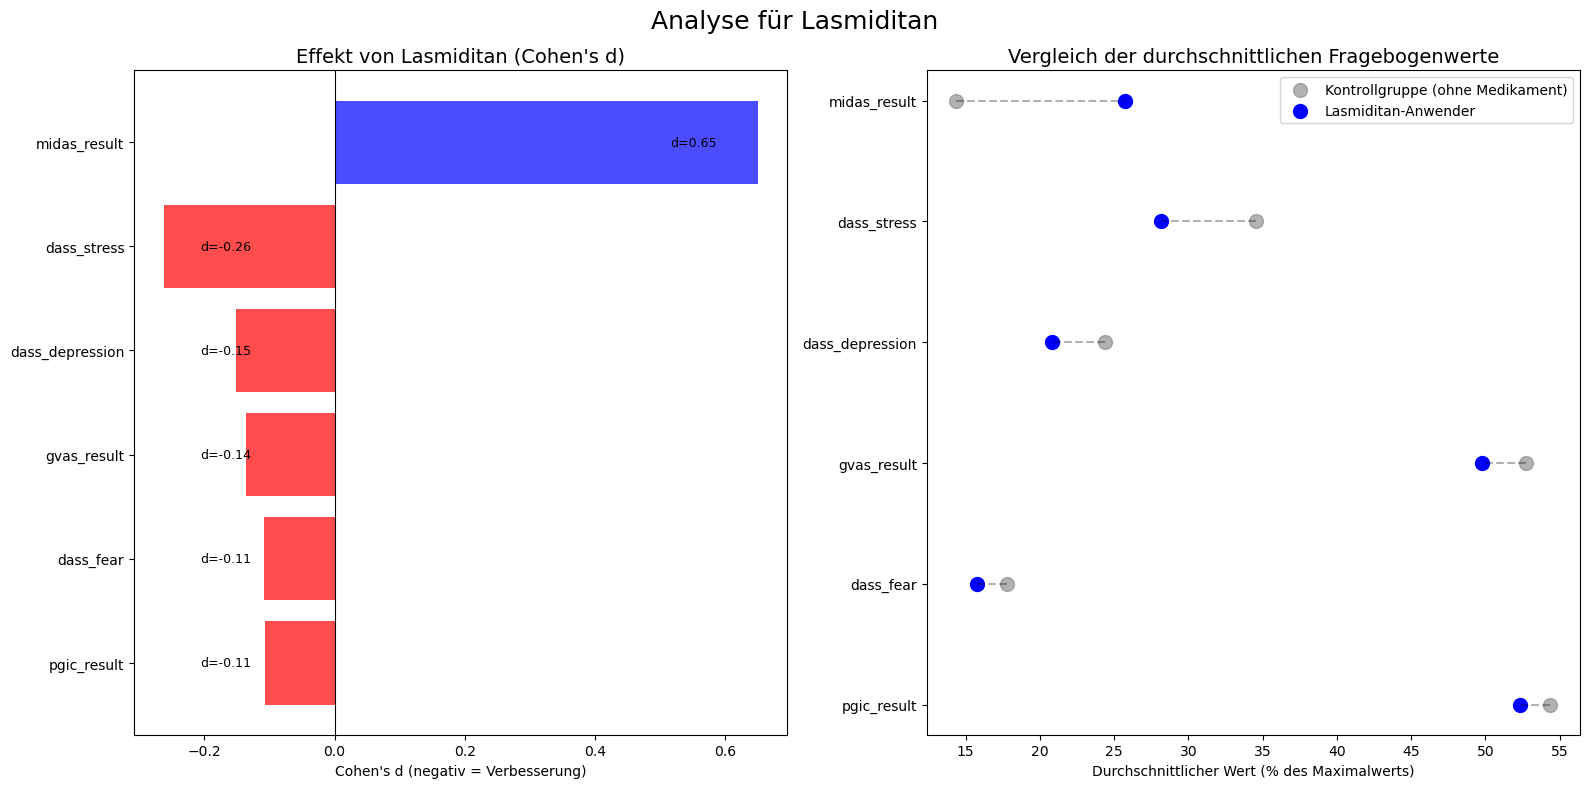

C:\Users\veron\AppData\Local\Temp\ipykernel_19892\3432615368.py:29: DtypeWarning: Columns (106,107,228,230,243,245,247,249,251,252,260,262,264,266,268,269,277,279,281,283,285,286,294,300,302,303,311,313,371,373,374,383,385,386,395,396,397,398,399,407,408,409,410,411,416,418,419,420,421,422,423,428,430,431,432,433,435,440,441,442,443,444,445,446,447,448,450,451,452,453,454,459,460,462,463,464,465,466,470,472,474,475,476,477,484,486,487,488,489,490,496,498,499,501,502,508,510,511,513,730,735,737,755,756,761,762,763,777,779,781,782,788,791,799,801,803,805,808,814,817,825,827,829,1016,1024,1028,1033,1034,1040,1041,1042,1046,1048,1051,1052,1058,1059,1060,1064,1066,1069,1070,1076,1077,1078,1082,1084,1087,1094,1095,1096,1099,1100,1102,1105,1112,1113,1114,1115,1117,1118,1120,1123,1124,1130,1131,1132,1133,1134,1135,1136,1138,1141,1144,1145,1148,1149,1151,1152,1153,1156,1161,1162,1163,1166,1167,1169,1170,1171,1174,1177,1178,1179,1180,1181,1184,1185,1187,1188,1189,1195,1197,1198,1199,1202,1203,12

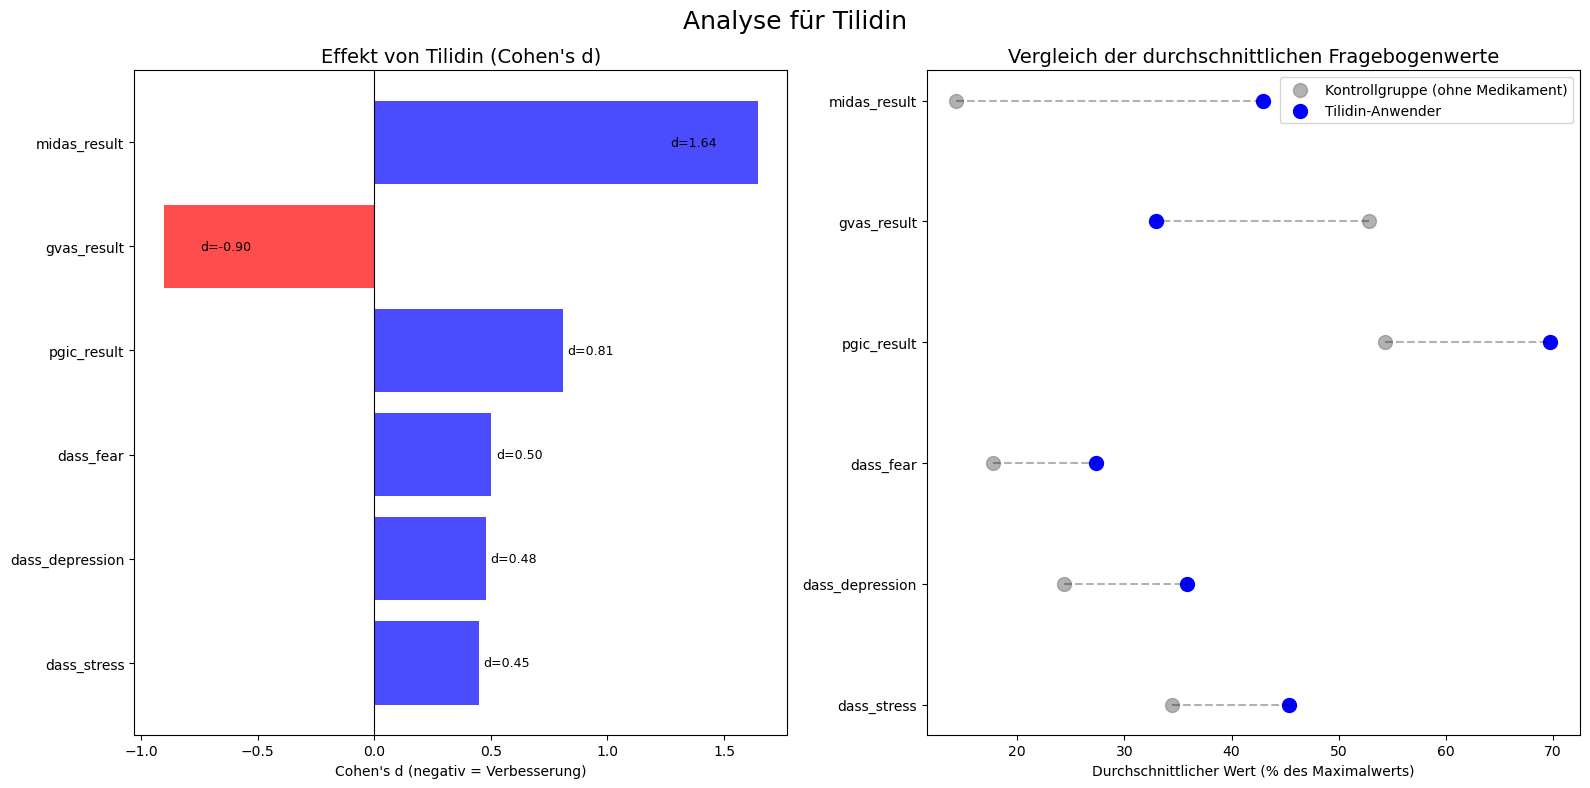

C:\Users\veron\AppData\Local\Temp\ipykernel_19892\3432615368.py:29: DtypeWarning: Columns (106,107,228,230,243,245,247,249,251,252,260,262,264,266,268,269,277,279,281,283,285,286,294,300,302,303,311,313,371,373,374,383,385,386,395,396,397,398,399,407,408,409,410,411,416,418,419,420,421,422,423,428,430,431,432,433,435,440,441,442,443,444,445,446,447,448,450,451,452,453,454,459,460,462,463,464,465,466,470,472,474,475,476,477,484,486,487,488,489,490,496,498,499,501,502,508,510,511,513,730,735,737,755,756,761,762,763,777,779,781,782,788,791,799,801,803,805,808,814,817,825,827,829,1016,1024,1028,1033,1034,1040,1041,1042,1046,1048,1051,1052,1058,1059,1060,1064,1066,1069,1070,1076,1077,1078,1082,1084,1087,1094,1095,1096,1099,1100,1102,1105,1112,1113,1114,1115,1117,1118,1120,1123,1124,1130,1131,1132,1133,1134,1135,1136,1138,1141,1144,1145,1148,1149,1151,1152,1153,1156,1161,1162,1163,1166,1167,1169,1170,1171,1174,1177,1178,1179,1180,1181,1184,1185,1187,1188,1189,1195,1197,1198,1199,1202,1203,12

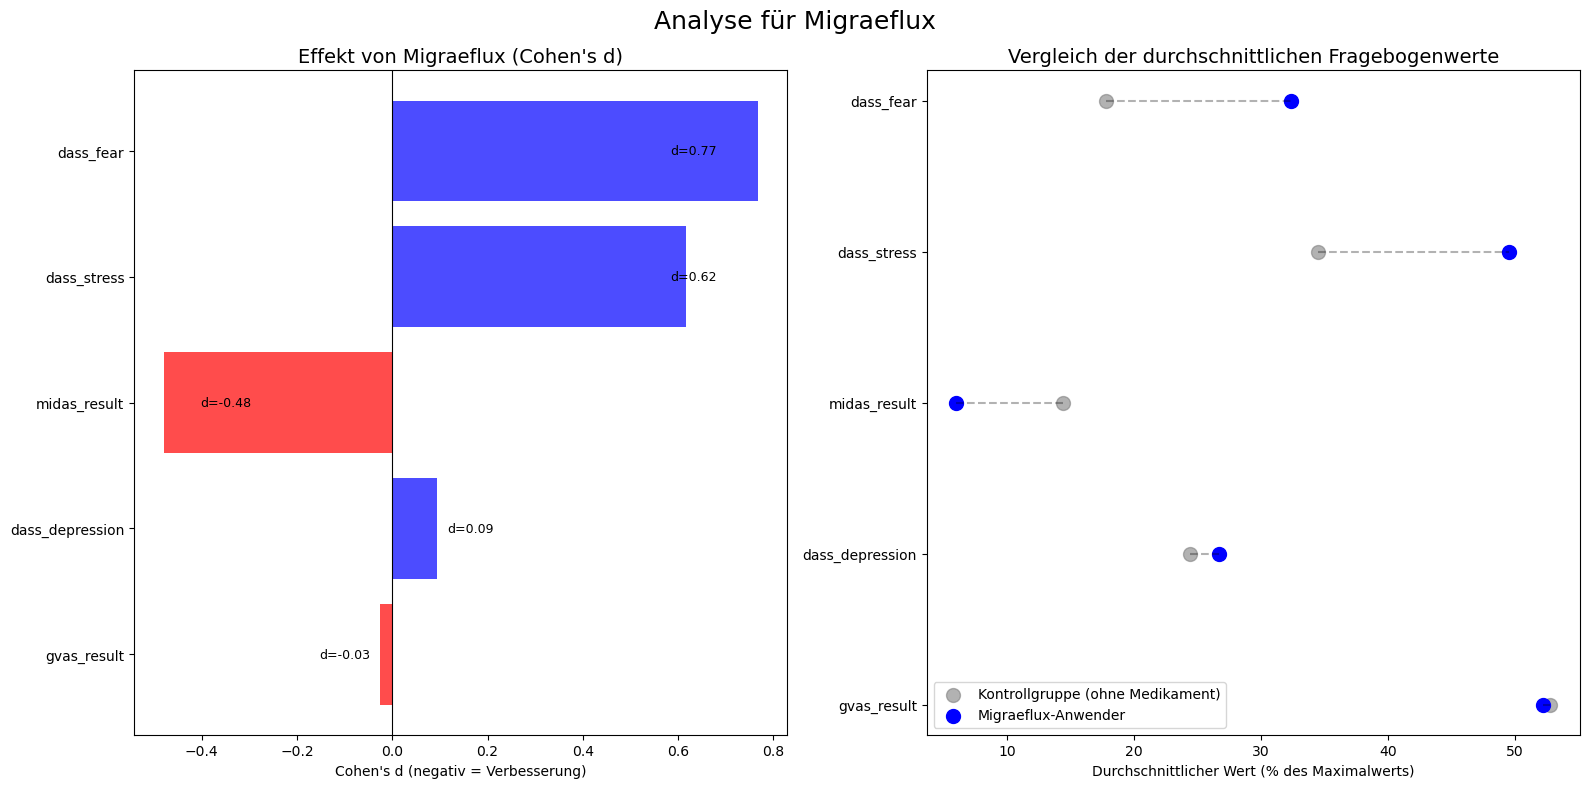

C:\Users\veron\AppData\Local\Temp\ipykernel_19892\3432615368.py:29: DtypeWarning: Columns (106,107,228,230,243,245,247,249,251,252,260,262,264,266,268,269,277,279,281,283,285,286,294,300,302,303,311,313,371,373,374,383,385,386,395,396,397,398,399,407,408,409,410,411,416,418,419,420,421,422,423,428,430,431,432,433,435,440,441,442,443,444,445,446,447,448,450,451,452,453,454,459,460,462,463,464,465,466,470,472,474,475,476,477,484,486,487,488,489,490,496,498,499,501,502,508,510,511,513,730,735,737,755,756,761,762,763,777,779,781,782,788,791,799,801,803,805,808,814,817,825,827,829,1016,1024,1028,1033,1034,1040,1041,1042,1046,1048,1051,1052,1058,1059,1060,1064,1066,1069,1070,1076,1077,1078,1082,1084,1087,1094,1095,1096,1099,1100,1102,1105,1112,1113,1114,1115,1117,1118,1120,1123,1124,1130,1131,1132,1133,1134,1135,1136,1138,1141,1144,1145,1148,1149,1151,1152,1153,1156,1161,1162,1163,1166,1167,1169,1170,1171,1174,1177,1178,1179,1180,1181,1184,1185,1187,1188,1189,1195,1197,1198,1199,1202,1203,12

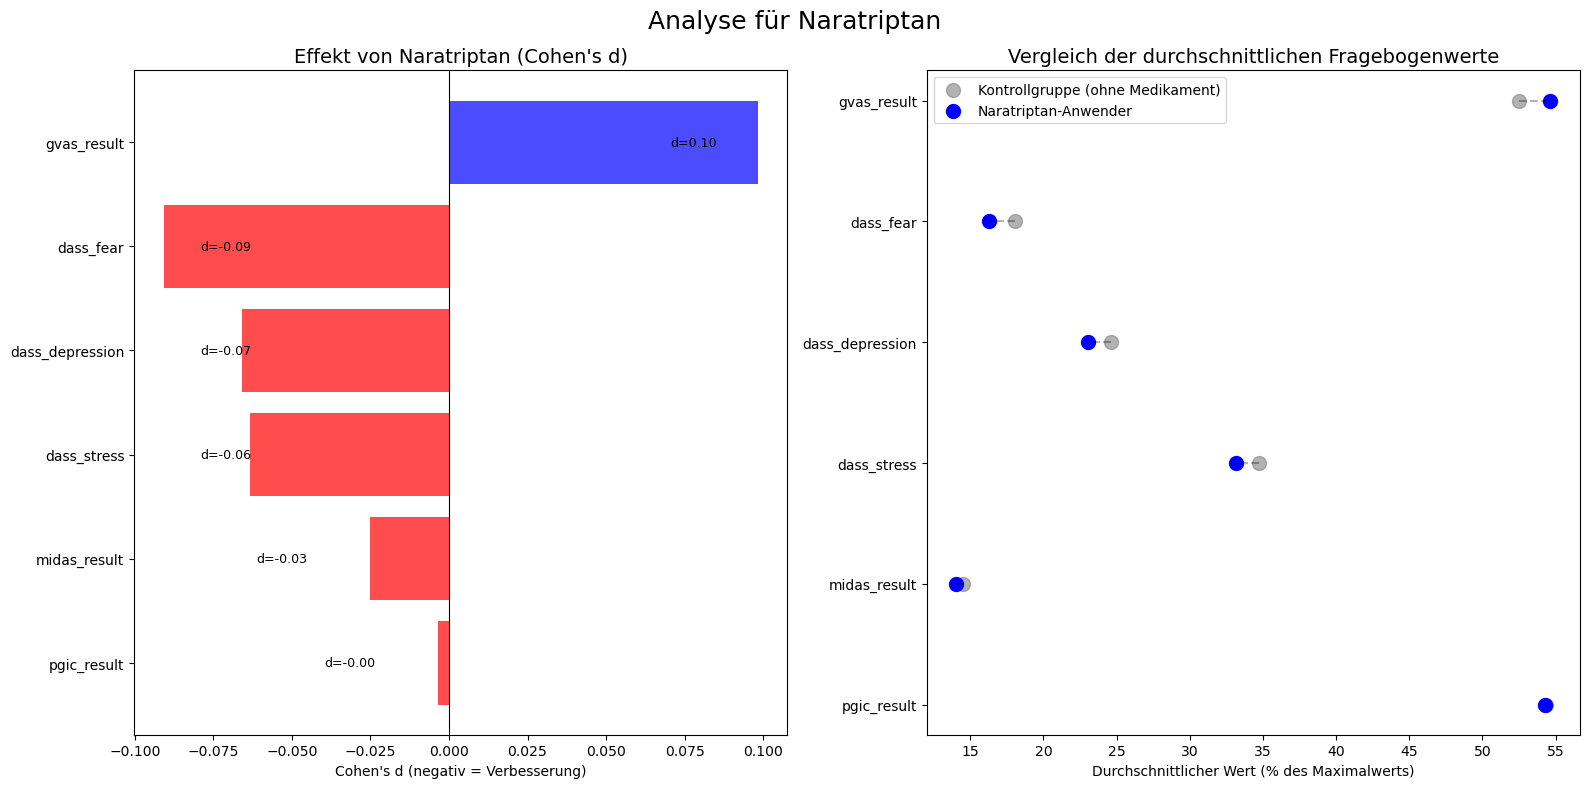

In [2]:
# =========================================================
# ALL MEDICATIONS — SEPARATE ANALYSES
# =========================================================

MEDICATIONS = [
    "Metamizol",
    "Spalt®Schmerztabletten",
    "Tramadol",
    "Rizatriptan",
    "Lasmiditan",
    "Tilidin",
    "Migraeflux",
    "Naratriptan"
]

for medication in MEDICATIONS:

    MEDICATION_QUERY = medication
    pattern = rf"\b{re.escape(MEDICATION_QUERY)}"

    # =====================================================
    # DATEN LADEN
    # =====================================================

    combined_data = []

    for file in csv_files:

        df = pd.read_csv(file, sep=";")

        med_cols = [
            c for c in df.columns
            if c.startswith("acute_name_a")
        ]

        if not med_cols:
            continue

        df["has_med"] = (
            df[med_cols]
            .astype(str)
            .agg(" ".join, axis=1)
            .str.contains(
                pattern,
                case=False,
                na=False
            )
        )

        relevant_cols = ["has_med"]

        for base in score_bases:

            cols = [
                c for c in df.columns
                if c.startswith(base)
            ]

            if cols:

                df[f"score_{base}"] = (
                    df[cols]
                    .apply(
                        lambda x:
                        pd.to_numeric(
                            x.astype(str)
                            .str.replace(",", "."),
                            errors="coerce"
                        )
                    )
                    .mean(axis=1)
                )

                relevant_cols.append(
                    f"score_{base}"
                )

        combined_data.append(
            df[relevant_cols]
        )

    # Falls für dieses Medikament keine Daten vorhanden sind
    if not combined_data:
        print(
            f"Keine Daten für {MEDICATION_QUERY} gefunden."
        )
        continue

    data = pd.concat(
        combined_data,
        ignore_index=True
    )


    # =====================================================
    # ANALYSE
    # =====================================================

    results = []

    for base in score_bases:

        col = f"score_{base}"

        if col not in data.columns:
            continue

        tmp = data[
            ["has_med", col]
        ].dropna()

        med_s = tmp[
            tmp["has_med"]
        ][col]

        ctrl_s = tmp[
            ~tmp["has_med"]
        ][col]

        if len(med_s) < 5 or len(ctrl_s) < 5:
            continue

        max_range = score_ranges.get(
            base,
            100
        )

        med_pct = (
            med_s / max_range
        ) * 100

        ctrl_pct = (
            ctrl_s / max_range
        ) * 100

        pooled_std = np.sqrt(
            (
                (len(med_pct) - 1)
                * med_pct.var()
                +
                (len(ctrl_pct) - 1)
                * ctrl_pct.var()
            )
            /
            (
                len(med_pct)
                +
                len(ctrl_pct)
                -
                2
            )
        )

        d = (
            med_pct.mean()
            -
            ctrl_pct.mean()
        ) / pooled_std \
            if pooled_std != 0 else 0

        results.append({
            "questionnaire": base,
            "mean_med_pct": med_pct.mean(),
            "mean_ctrl_pct": ctrl_pct.mean(),
            "cohens_d": d,
            "n_med": len(med_s),
            "n_ctrl": len(ctrl_s)
        })


    # =====================================================
    # WICHTIG:
    # Falls keine Skala die Mindestanzahl an Werten erreicht,
    # wird dieses Medikament übersprungen.
    # =====================================================

    if not results:

        print(
            f"Keine ausreichenden Daten für "
            f"{MEDICATION_QUERY}."
        )

        continue


    res = pd.DataFrame(
        results
    ).sort_values(
        "cohens_d",
        key=abs
    )

    res["questionnaire_wrapped"] = (
        res["questionnaire"]
        .apply(
            lambda x:
            textwrap.fill(
                str(x),
                width=15
            )
        )
    )


    # =====================================================
    # DARSTELLUNG
    # =====================================================

    fig, (
        ax1,
        ax2
    ) = plt.subplots(
        1,
        2,
        figsize=(16, 8)
    )


    # -----------------------------------------------------
    # DIAGRAMM 1: COHEN'S D
    # -----------------------------------------------------

    colors = [
        "red"
        if x < 0
        else "blue"
        for x in res["cohens_d"]
    ]

    bars = ax1.barh(
        res["questionnaire_wrapped"],
        res["cohens_d"],
        color=colors,
        alpha=0.7
    )

    ax1.axvline(
        0,
        color="black",
        linewidth=0.8
    )

    ax1.set_title(
        f"Effekt von {MEDICATION_QUERY} (Cohen's d)",
        fontsize=14
    )

    ax1.set_xlabel(
        "Cohen's d (negativ = Verbesserung)"
    )

    for i, bar in enumerate(bars):

        val = res["cohens_d"].iloc[i]

        x_min, x_max = ax1.get_xlim()
        x_range = x_max - x_min

        # Beschriftung deutlich weiter vom Rand entfernt platzieren
        edge_margin = 0.18 * x_range

        if val >= 0:
            x_pos = min(
                val + 0.02,
                x_max - edge_margin
            )
            ha = "left"

        else:
            x_pos = max(
                val - 0.02,
                x_min + edge_margin
            )
            ha = "right"

        ax1.text(
            x_pos,
            bar.get_y()
            + bar.get_height()
            / 2,
            f"d={val:.2f}",
            va="center",
            ha=ha,
            fontsize=9
        )


    # -----------------------------------------------------
    # DIAGRAMM 2: DIREKTER VERGLEICH
    # -----------------------------------------------------

    y = np.arange(
        len(res)
    )

    ax2.scatter(
        res["mean_ctrl_pct"],
        y,
        color="gray",
        label="Kontrollgruppe (ohne Medikament)",
        s=100,
        alpha=0.6
    )

    ax2.scatter(
        res["mean_med_pct"],
        y,
        color="blue",
        label=f"{MEDICATION_QUERY}-Anwender",
        s=100
    )

    for i in range(
        len(res)
    ):

        ax2.plot(
            [
                res[
                    "mean_ctrl_pct"
                ].iloc[i],

                res[
                    "mean_med_pct"
                ].iloc[i]
            ],

            [
                i,
                i
            ],

            color="black",
            alpha=0.3,
            linestyle="--"
        )


    ax2.set_yticks(
        y
    )

    ax2.set_yticklabels(
        res[
            "questionnaire_wrapped"
        ]
    )

    ax2.set_xlabel(
        "Durchschnittlicher Wert (% des Maximalwerts)"
    )

    ax2.set_title(
        "Vergleich der durchschnittlichen Fragebogenwerte",
        fontsize=14
    )

    ax2.legend()


    plt.suptitle(
        f"Analyse für {MEDICATION_QUERY}",
        fontsize=18
    )

    plt.tight_layout()

    plt.show()

C:\Users\veron\AppData\Local\Temp\ipykernel_19892\4134271926.py:68: DtypeWarning: Columns (106,107,228,230,243,245,247,249,251,252,260,262,264,266,268,269,277,279,281,283,285,286,294,300,302,303,311,313,371,373,374,383,385,386,395,396,397,398,399,407,408,409,410,411,416,418,419,420,421,422,423,428,430,431,432,433,435,440,441,442,443,444,445,446,447,448,450,451,452,453,454,459,460,462,463,464,465,466,470,472,474,475,476,477,484,486,487,488,489,490,496,498,499,501,502,508,510,511,513,730,735,737,755,756,761,762,763,777,779,781,782,788,791,799,801,803,805,808,814,817,825,827,829,1016,1024,1028,1033,1034,1040,1041,1042,1046,1048,1051,1052,1058,1059,1060,1064,1066,1069,1070,1076,1077,1078,1082,1084,1087,1094,1095,1096,1099,1100,1102,1105,1112,1113,1114,1115,1117,1118,1120,1123,1124,1130,1131,1132,1133,1134,1135,1136,1138,1141,1144,1145,1148,1149,1151,1152,1153,1156,1161,1162,1163,1166,1167,1169,1170,1171,1174,1177,1178,1179,1180,1181,1184,1185,1187,1188,1189,1195,1197,1198,1199,1202,1203,12

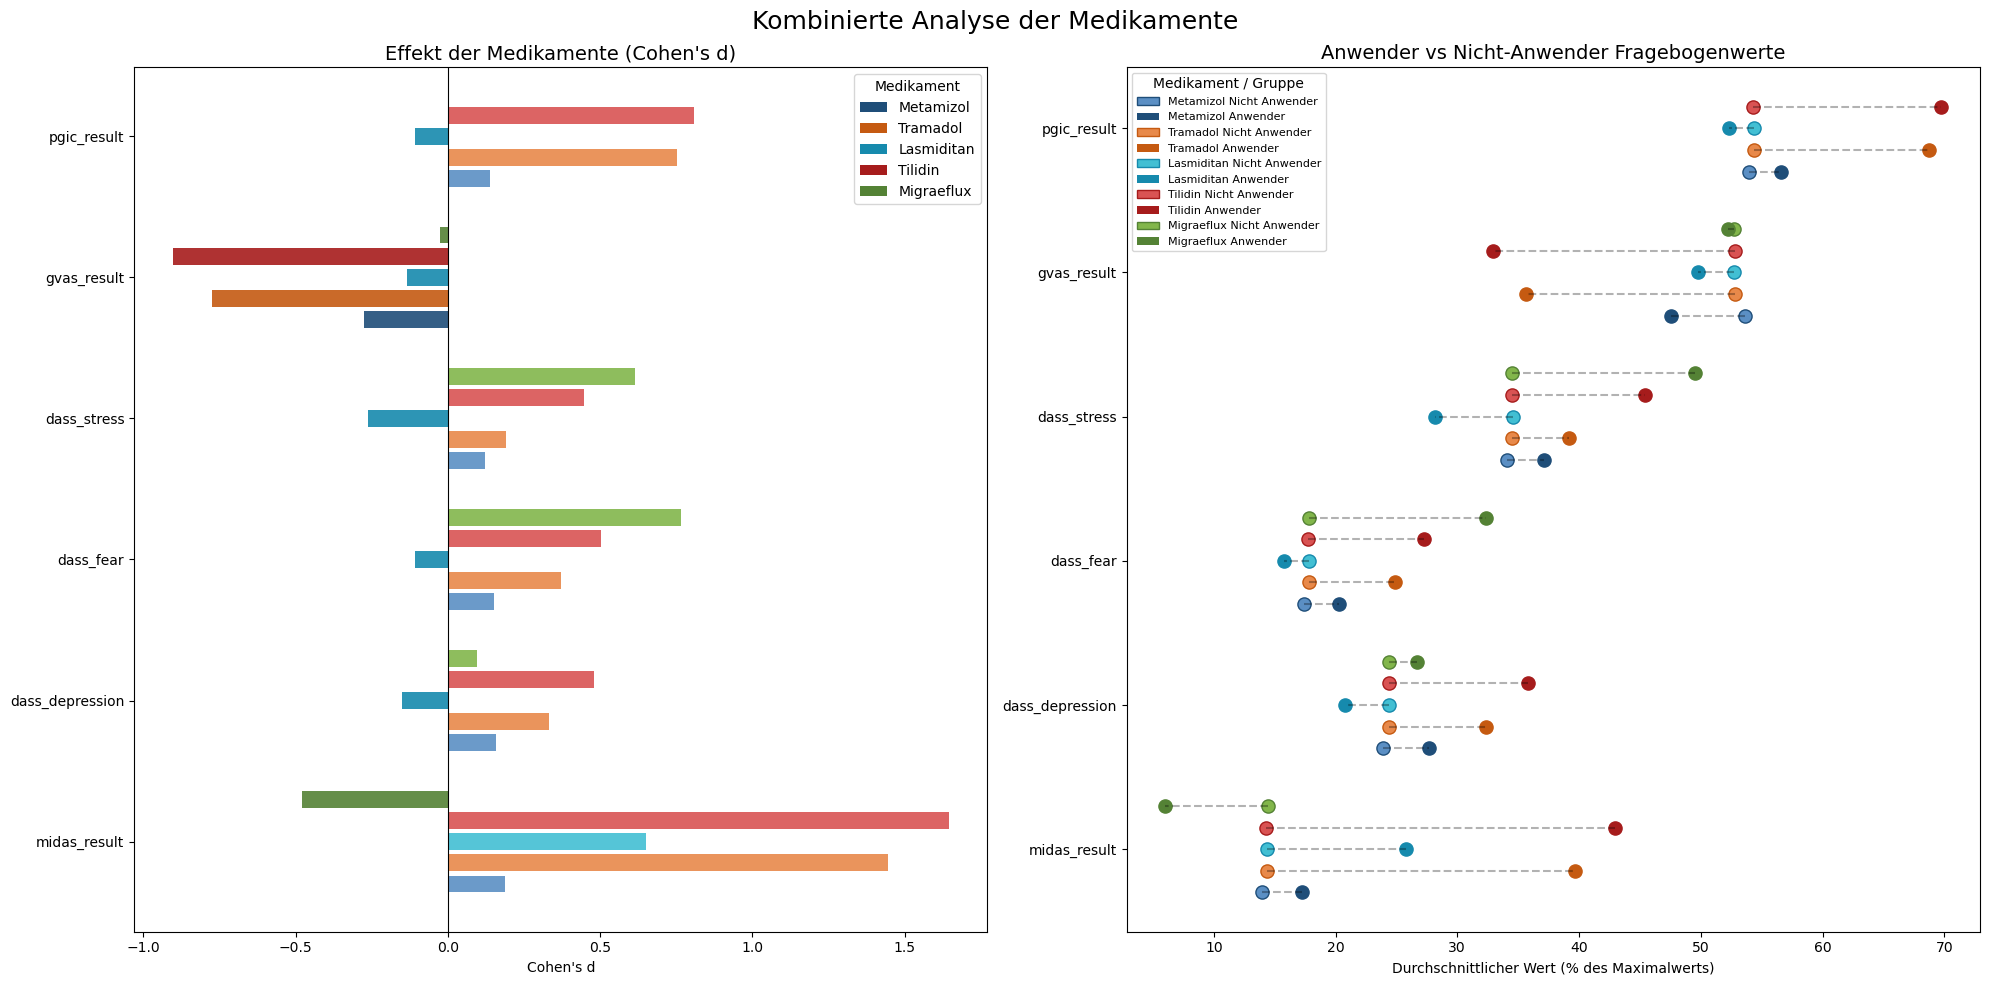

In [3]:
# =========================================================
# KOMBINIERTE ANALYSE MEHRERER MEDIKAMENTE
# =========================================================

COMBINED_MEDICATIONS = [
    "Metamizol",
    "Tramadol",
    "Lasmiditan",
    "Tilidin",
    "Migraeflux"
]

# =========================================================
# FARBSCHEMA
# Dunkel = Medikamentengruppe
# Hell   = Kontrollgruppe
# =========================================================

MEDICATION_COLORS = {

    # Blau
    "Metamizol": {
        "dark": "#1F4E79",
        "light": "#5B8FC4"
    },

    # Orange
    "Tramadol": {
        "dark": "#C55A11",
        "light": "#E8894A"
    },

    # Türkis / Cyan
    "Lasmiditan": {
        "dark": "#168AAD",
        "light": "#42BFD3"
    },

    # Rot
    "Tilidin": {
        "dark": "#A61C1C",
        "light": "#D95353"
    },

    # Grün
    "Migraeflux": {
        "dark": "#548235",
        "light": "#82B64B"
    }

}
# =========================================================
# DATEN LADEN
# =========================================================

combined_results = []


for medication in COMBINED_MEDICATIONS:

    pattern = rf"\b{re.escape(medication)}"

    combined_data = []


    for file in csv_files:

        df = pd.read_csv(
            file,
            sep=";"
        )


        med_cols = [
            c for c in df.columns
            if c.startswith("acute_name_a")
        ]


        if not med_cols:
            continue


        df["has_med"] = (

            df[med_cols]
            .astype(str)
            .agg(" ".join, axis=1)
            .str.contains(
                pattern,
                case=False,
                na=False
            )

        )


        relevant_cols = [
            "has_med"
        ]


        for base in score_bases:

            cols = [
                c for c in df.columns
                if c.startswith(base)
            ]


            if cols:

                df[f"score_{base}"] = (

                    df[cols]
                    .apply(

                        lambda x:

                        pd.to_numeric(

                            x.astype(str)
                            .str.replace(
                                ",",
                                "."
                            ),

                            errors="coerce"

                        )

                    )
                    .mean(axis=1)

                )


                relevant_cols.append(
                    f"score_{base}"
                )


        combined_data.append(
            df[relevant_cols]
        )


    if not combined_data:

        print(
            f"Keine Daten für "
            f"{medication} gefunden."
        )

        continue


    medication_data = pd.concat(
        combined_data,
        ignore_index=True
    )


    # =====================================================
    # ANALYSE
    # =====================================================

    for base in score_bases:

        col = f"score_{base}"


        if col not in medication_data.columns:

            continue


        tmp = medication_data[
            [
                "has_med",
                col
            ]
        ].dropna()


        med_s = tmp[
            tmp["has_med"]
        ][col]


        ctrl_s = tmp[
            ~tmp["has_med"]
        ][col]


        if len(med_s) < 5 or len(ctrl_s) < 5:

            continue


        max_range = score_ranges.get(
            base,
            100
        )


        med_pct = (
            med_s
            /
            max_range
        ) * 100


        ctrl_pct = (
            ctrl_s
            /
            max_range
        ) * 100


        pooled_std = np.sqrt(

            (

                (len(med_pct) - 1)
                * med_pct.var()

                +

                (len(ctrl_pct) - 1)
                * ctrl_pct.var()

            )

            /

            (

                len(med_pct)
                +
                len(ctrl_pct)
                -
                2

            )

        )


        if pooled_std != 0:

            d = (
                med_pct.mean()
                -
                ctrl_pct.mean()
            ) / pooled_std

        else:

            d = 0


        combined_results.append({

            "medication": medication,

            "questionnaire": base,

            "mean_med_pct":
                med_pct.mean(),

            "mean_ctrl_pct":
                ctrl_pct.mean(),

            "cohens_d": d,

            "n_med":
                len(med_s),

            "n_ctrl":
                len(ctrl_s)

        })


# =========================================================
# DATAFRAME
# =========================================================

combined_res = pd.DataFrame(
    combined_results
)


if combined_res.empty:

    print(
        "Keine ausreichenden Daten "
        "für die kombinierte Analyse."
    )


else:

    # =====================================================
    # FRAGEBOGEN-REIHENFOLGE
    # UNVERÄNDERT ZUM ORIGINAL
    # =====================================================

    questionnaire_order = [

        base

        for base in score_bases

        if base in
        combined_res[
            "questionnaire"
        ].unique()

    ]


    # =====================================================
    # DIAGRAMME
    # =====================================================

    fig, (
        ax1,
        ax2
    ) = plt.subplots(

        1,
        2,

        figsize=(20, 10)

    )


    # =====================================================
    # DIAGRAMM 1:
    # COHEN'S d
    # =====================================================

    # Für jedes Medikament werden die Werte
    # pro Fragebogen leicht versetzt dargestellt.
    #
    # Die Y-Achse zeigt weiterhin ausschließlich
    # die ursprünglichen Fragebogennamen.

    y = np.arange(
        len(questionnaire_order)
    )


    medication_offsets = np.linspace(

        -0.30,

        0.30,

        len(COMBINED_MEDICATIONS)

    )


    for medication, offset in zip(

        COMBINED_MEDICATIONS,

        medication_offsets

    ):


        medication_res = combined_res[

            combined_res[
                "medication"
            ]

            == medication

        ]


        medication_res = (

            medication_res

            .set_index(
                "questionnaire"
            )

            .reindex(
                questionnaire_order
            )

        )


        valid = (
            medication_res[
                "cohens_d"
            ]
            .notna()
        )


        for position, value in zip(

            y[valid] + offset,

            medication_res[
                "cohens_d"
            ][valid]

        ):

            if value < 0:

                bar_color = MEDICATION_COLORS[
                    medication
                ]["dark"]

            else:

                bar_color = MEDICATION_COLORS[
                    medication
                ]["light"]


            ax1.barh(

                position,

                value,

                height=0.12,

                color=bar_color,

                alpha=0.9

            )


    ax1.axvline(

        0,

        color="black",

        linewidth=0.8

    )


    # UNVERÄNDERTE Y-ACHSENBESCHRIFTUNG

    ax1.set_yticks(
        y
    )


    ax1.set_yticklabels(

        questionnaire_order

    )


    # UNVERÄNDERTE X-ACHSENBESCHRIFTUNG

    ax1.set_xlabel(

        "Cohen's d"

    )


    ax1.set_title(

        "Effekt der Medikamente (Cohen's d)",

        fontsize=14

    )


    # =====================================================
    # FARB-LEGENDE FÜR MEDIKAMENTE
    # =====================================================

    from matplotlib.patches import Patch


    medication_legend = []


    for medication in COMBINED_MEDICATIONS:

        medication_legend.append(

            Patch(

                facecolor=

                MEDICATION_COLORS[
                    medication
                ]["dark"],

                label=medication

            )

        )


    ax1.legend(

        handles=medication_legend,

        title="Medikament",

        loc="best"

    )


    # =====================================================
    # DIAGRAMM 2:
    # DIREKTER VERGLEICH
    # =====================================================

    # Y-Achse bleibt exakt auf den Fragebögen.
    #
    # Die fünf Medikamente werden pro Fragebogen
    # nebeneinander dargestellt.

    y = np.arange(

        len(questionnaire_order)

    )


    medication_offsets = np.linspace(

        -0.30,

        0.30,

        len(COMBINED_MEDICATIONS)

    )


    for medication, offset in zip(

        COMBINED_MEDICATIONS,

        medication_offsets

    ):


        medication_res = combined_res[

            combined_res[
                "medication"
            ]

            == medication

        ]


        medication_res = (

            medication_res

            .set_index(
                "questionnaire"
            )

            .reindex(
                questionnaire_order
            )

        )


        valid = (

            medication_res[
                "mean_ctrl_pct"
            ]
            .notna()

            &

            medication_res[
                "mean_med_pct"
            ]
            .notna()

        )


        # Verbindungslinie

        for i in y[valid]:

            ctrl_value = (

                medication_res[
                    "mean_ctrl_pct"
                ].iloc[i]

            )


            med_value = (

                medication_res[
                    "mean_med_pct"
                ].iloc[i]

            )


            ax2.plot(

                [

                    ctrl_value,

                    med_value

                ],

                [

                    i + offset,

                    i + offset

                ],

                color="black",

                alpha=0.3,

                linestyle="--"

            )


        # Kontrollgruppe = helle Farbe

        ax2.scatter(

            medication_res[
                "mean_ctrl_pct"
            ][valid],

            y[valid] + offset,

            color=MEDICATION_COLORS[
                medication
            ]["light"],

            edgecolor=MEDICATION_COLORS[
                medication
            ]["dark"],

            s=90

        )


        # Medikamentengruppe = dunkle Farbe

        ax2.scatter(

            medication_res[
                "mean_med_pct"
            ][valid],

            y[valid] + offset,

            color=MEDICATION_COLORS[
                medication
            ]["dark"],

            s=90

        )


    # UNVERÄNDERTE Y-ACHSENBESCHRIFTUNG

    ax2.set_yticks(

        y

    )


    ax2.set_yticklabels(

        questionnaire_order

    )


    # UNVERÄNDERTE X-ACHSENBESCHRIFTUNG

    ax2.set_xlabel(

        "Durchschnittlicher Wert "
        "(% des Maximalwerts)"

    )


    ax2.set_title(

        "Anwender vs Nicht-Anwender "
        "Fragebogenwerte",

        fontsize=14

    )


    # =====================================================
    # LEGENDE
    # =====================================================

    legend_elements = []


    for medication in COMBINED_MEDICATIONS:


        # Kontrollgruppe

        legend_elements.append(

            Patch(

                facecolor=

                MEDICATION_COLORS[
                    medication
                ]["light"],

                edgecolor=

                MEDICATION_COLORS[
                    medication
                ]["dark"],

                label=(

                    f"{medication} "
                    "Nicht Anwender"

                )

            )

        )


        # Medikamentengruppe

        legend_elements.append(

            Patch(

                facecolor=

                MEDICATION_COLORS[
                    medication
                ]["dark"],

                label=(

                    f"{medication} "
                    "Anwender"

                )

            )

        )


    ax2.legend(

        handles=legend_elements,

        title="Medikament / Gruppe",

        fontsize=8,

        loc="best"

    )


    # =====================================================
    # GESAMTTITEL
    # =====================================================

    plt.suptitle(

        "Kombinierte Analyse der Medikamente",

        fontsize=18

    )


    plt.tight_layout()

    plt.show()

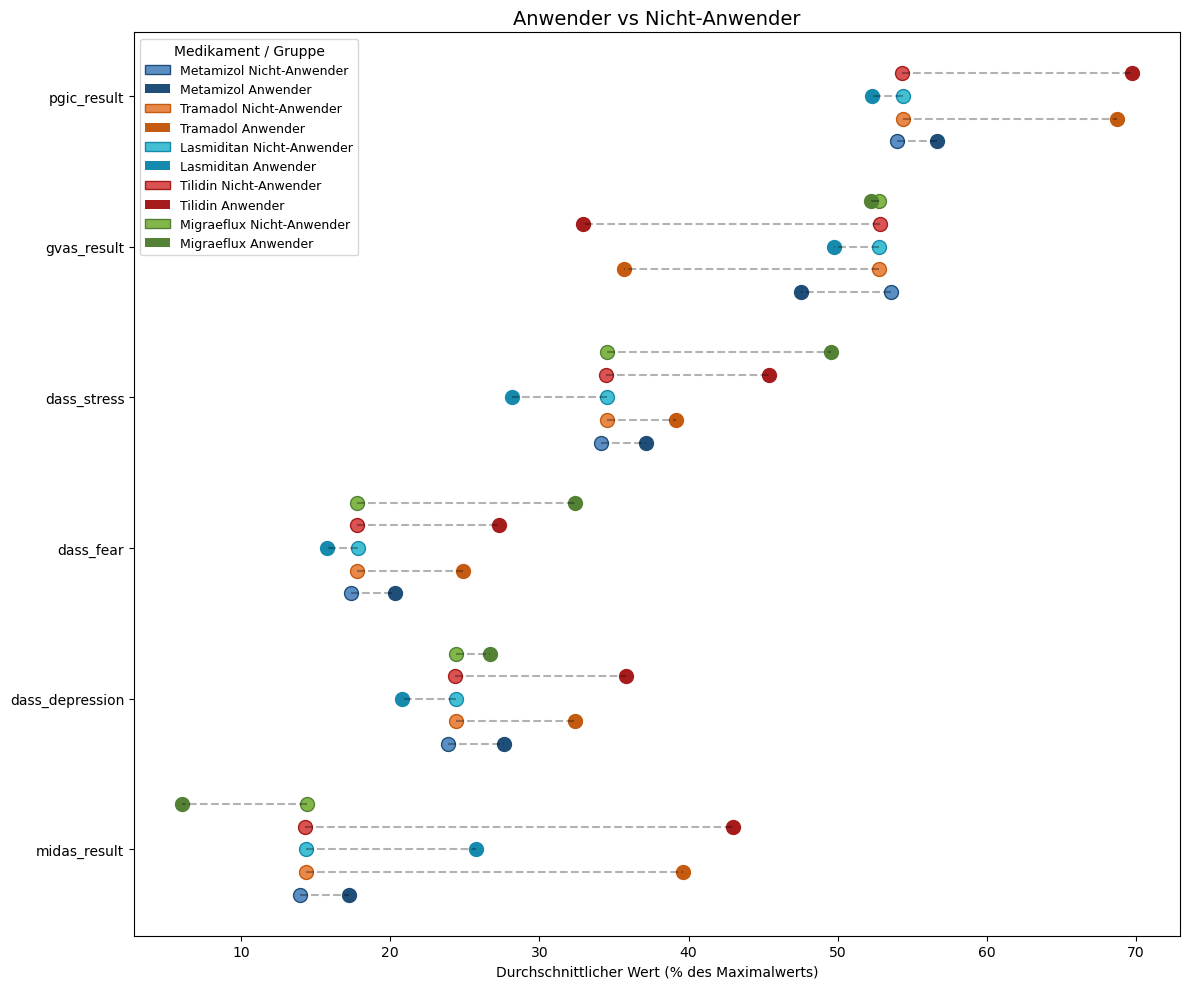

In [4]:
# =========================================================
# NUR RECHTES DIAGRAMM:
# DIREKTER VERGLEICH ALLER MEDIKAMENTE
# =========================================================

fig, ax2 = plt.subplots(
    figsize=(12, 10)
)


# =========================================================
# FRAGEBOGEN-REIHENFOLGE
# =========================================================

questionnaire_order = [

    base

    for base in score_bases

    if base in
    combined_res[
        "questionnaire"
    ].unique()

]


y = np.arange(
    len(questionnaire_order)
)


# =========================================================
# POSITIONEN DER MEDIKAMENTE
# =========================================================

medication_offsets = np.linspace(

    -0.30,

    0.30,

    len(COMBINED_MEDICATIONS)

)


# =========================================================
# MEDIKAMENTE ZEICHNEN
# =========================================================

for medication, offset in zip(

    COMBINED_MEDICATIONS,

    medication_offsets

):


    medication_res = combined_res[

        combined_res[
            "medication"
        ]

        == medication

    ]


    medication_res = (

        medication_res

        .set_index(
            "questionnaire"
        )

        .reindex(
            questionnaire_order
        )

    )


    valid = (

        medication_res[
            "mean_ctrl_pct"
        ]

        .notna()

        &

        medication_res[
            "mean_med_pct"
        ]

        .notna()

    )


    # =====================================================
    # VERBINDUNGSLINIEN
    # =====================================================

    for i in y[valid]:

        ctrl_value = (

            medication_res[
                "mean_ctrl_pct"
            ].iloc[i]

        )


        med_value = (

            medication_res[
                "mean_med_pct"
            ].iloc[i]

        )


        ax2.plot(

            [

                ctrl_value,

                med_value

            ],

            [

                i + offset,

                i + offset

            ],

            color="black",

            alpha=0.3,

            linestyle="--"

        )


    # =====================================================
    # KONTROLLGRUPPE
    # HELLE FARBE
    # =====================================================

    ax2.scatter(

        medication_res[
            "mean_ctrl_pct"
        ][valid],

        y[valid] + offset,

        color=MEDICATION_COLORS[
            medication
        ]["light"],

        edgecolor=MEDICATION_COLORS[
            medication
        ]["dark"],

        s=100

    )


    # =====================================================
    # MEDIKAMENTENGRUPPE
    # DUNKLE FARBE
    # =====================================================

    ax2.scatter(

        medication_res[
            "mean_med_pct"
        ][valid],

        y[valid] + offset,

        color=MEDICATION_COLORS[
            medication
        ]["dark"],

        s=100

    )


# =========================================================
# ACHSENBESCHRIFTUNGEN
# UNVERÄNDERT
# =========================================================

ax2.set_yticks(
    y
)


ax2.set_yticklabels(
    questionnaire_order
)


ax2.set_xlabel(

    "Durchschnittlicher Wert "
    "(% des Maximalwerts)"

)


ax2.set_title(

    "Anwender vs Nicht-Anwender",

    fontsize=14

)


# =========================================================
# LEGENDE
# =========================================================

from matplotlib.patches import Patch


legend_elements = []


for medication in COMBINED_MEDICATIONS:


    # Helle Farbe = Kontrollgruppe

    legend_elements.append(

        Patch(

            facecolor=

            MEDICATION_COLORS[
                medication
            ]["light"],

            edgecolor=

            MEDICATION_COLORS[
                medication
            ]["dark"],

            label=(

                f"{medication} "
                "Nicht-Anwender"

            )

        )

    )


    # Dunkle Farbe = Medikamentengruppe

    legend_elements.append(

        Patch(

            facecolor=

            MEDICATION_COLORS[
                medication
            ]["dark"],

            label=(

                f"{medication} "
                "Anwender"

            )

        )

    )


ax2.legend(

    handles=legend_elements,

    title="Medikament / Gruppe",

    fontsize=9,

    loc="best"

)


plt.tight_layout()

plt.show()

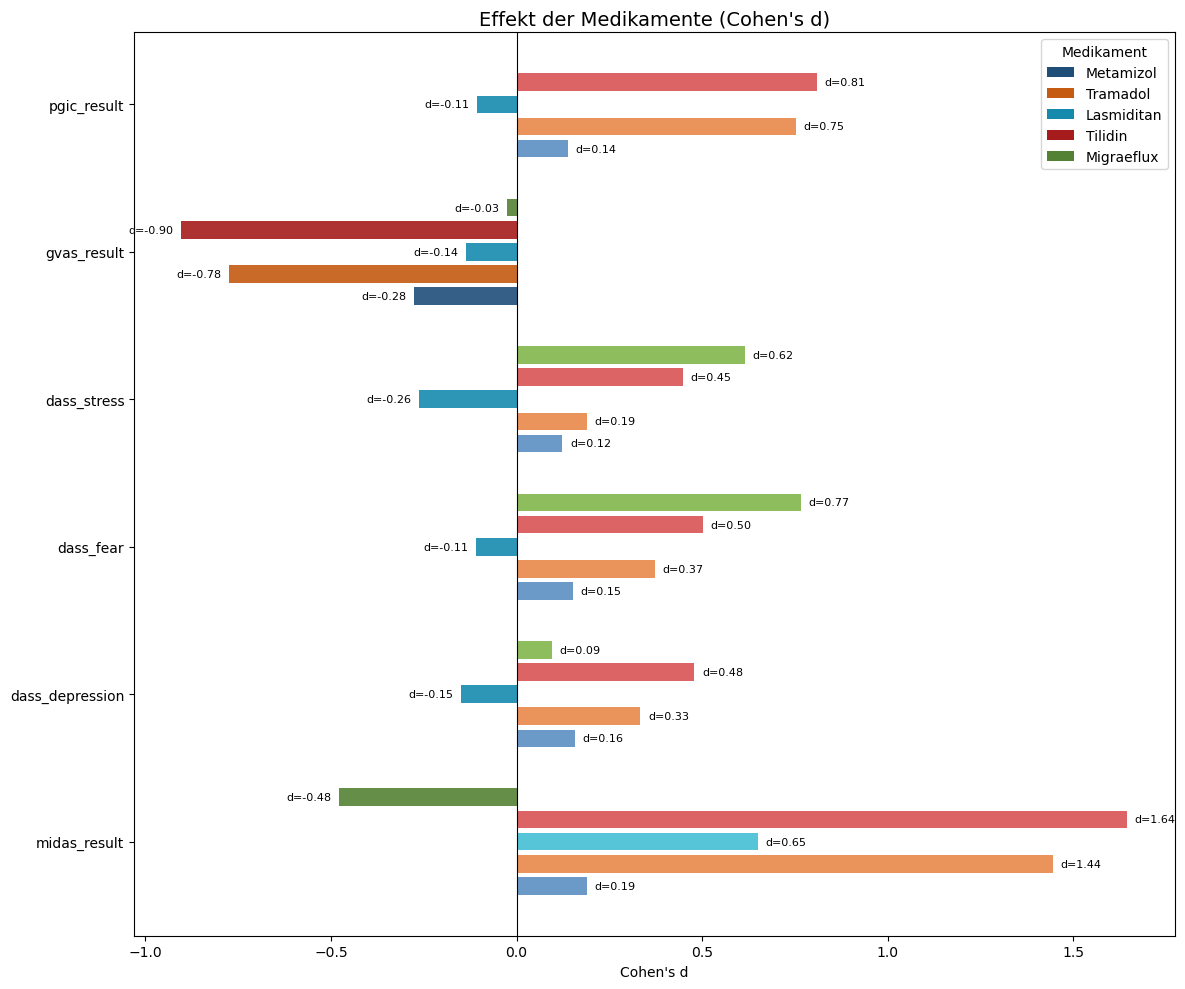

In [5]:
# =========================================================
# NUR LINKES DIAGRAMM:
# COHEN'S d FÜR ALLE MEDIKAMENTE
# =========================================================

fig, ax1 = plt.subplots(
    figsize=(12, 10)
)


# =========================================================
# FRAGEBOGEN-REIHENFOLGE
# =========================================================

questionnaire_order = [

    base

    for base in score_bases

    if base in
    combined_res[
        "questionnaire"
    ].unique()

]


y = np.arange(
    len(questionnaire_order)
)


# =========================================================
# POSITIONEN DER MEDIKAMENTE
# =========================================================

medication_offsets = np.linspace(

    -0.30,

    0.30,

    len(COMBINED_MEDICATIONS)

)


# =========================================================
# COHEN'S d ZEICHNEN
# =========================================================

for medication, offset in zip(

    COMBINED_MEDICATIONS,

    medication_offsets

):


    medication_res = combined_res[

        combined_res[
            "medication"
        ]

        == medication

    ]


    medication_res = (

        medication_res

        .set_index(
            "questionnaire"
        )

        .reindex(
            questionnaire_order
        )

    )


    valid = (

        medication_res[
            "cohens_d"
        ]

        .notna()

    )


    # =====================================================
    # ZWEIFARBIGE STRUKTUR
    #
    # NEGATIVER d = DUNKLE FARBE
    # POSITIVER d = HELLE FARBE
    # =====================================================

    for position, value in zip(

        y[valid] + offset,

        medication_res[
            "cohens_d"
        ][valid]

    ):


        if value < 0:

            bar_color = MEDICATION_COLORS[
                medication
            ]["dark"]

        else:

            bar_color = MEDICATION_COLORS[
                medication
            ]["light"]


        ax1.barh(

            position,

            value,

            height=0.12,

            color=bar_color,

            alpha=0.9

        )


# =========================================================
# NULL-LINIE
# =========================================================

ax1.axvline(

    0,

    color="black",

    linewidth=0.8

)


# =========================================================
# ACHSENBESCHRIFTUNGEN
# UNVERÄNDERT
# =========================================================

ax1.set_yticks(

    y

)


ax1.set_yticklabels(

    questionnaire_order

)


ax1.set_xlabel(

    "Cohen's d"

)


ax1.set_title(

    "Effekt der Medikamente (Cohen's d)",

    fontsize=14

)


# =========================================================
# WERTEBESCHRIFTUNG
# =========================================================

for medication, offset in zip(

    COMBINED_MEDICATIONS,

    medication_offsets

):


    medication_res = combined_res[

        combined_res[
            "medication"
        ]

        == medication

    ]


    medication_res = (

        medication_res

        .set_index(
            "questionnaire"
        )

        .reindex(
            questionnaire_order
        )

    )


    valid = (

        medication_res[
            "cohens_d"
        ]

        .notna()

    )


    for position, value in zip(

        y[valid] + offset,

        medication_res[
            "cohens_d"
        ][valid]

    ):


        if value >= 0:

            ax1.text(

                value + 0.02,

                position,

                f"d={value:.2f}",

                va="center",

                ha="left",

                fontsize=8

            )

        else:

            ax1.text(

                value - 0.02,

                position,

                f"d={value:.2f}",

                va="center",

                ha="right",

                fontsize=8

            )


# =========================================================
# LEGENDE
# =========================================================

from matplotlib.patches import Patch


legend_elements = []


medication_legend = []


for medication in COMBINED_MEDICATIONS:

    medication_legend.append(

        Patch(

            facecolor=

            MEDICATION_COLORS[
                medication
            ]["dark"],

            label=medication

        )

    )


ax1.legend(

    handles=medication_legend,

    title="Medikament",

    loc="best"

)





plt.tight_layout()

plt.show()

In [6]:
# =========================================================
# VOLLSTÄNDIGE ANALYSE DER 5 MEDIKAMENTE
# ANWENDER VS. NICHT-ANWENDER
# =========================================================

from scipy.stats import ttest_ind

full_analysis_results = []


# =========================================================
# MEDIKAMENTE EINZELN ANALYSIEREN
# =========================================================

for medication in COMBINED_MEDICATIONS:

    pattern = rf"\b{re.escape(medication)}"

    medication_data_list = []


    # -----------------------------------------------------
    # DATEN LADEN
    # -----------------------------------------------------

    for file in csv_files:

        df = pd.read_csv(
            file,
            sep=";"
        )

        med_cols = [
            c
            for c in df.columns
            if c.startswith("acute_name_a")
        ]

        if not med_cols:
            continue


        # Medikament vorhanden: True / False

        df["has_med"] = (

            df[med_cols]
            .astype(str)
            .agg(" ".join, axis=1)
            .str.contains(
                pattern,
                case=False,
                na=False
            )

        )


        relevant_cols = [
            "has_med"
        ]


        # -------------------------------------------------
        # FRAGEBOGENWERTE BERECHNEN
        # -------------------------------------------------

        for base in score_bases:

            cols = [
                c
                for c in df.columns
                if c.startswith(base)
            ]

            if cols:

                df[
                    f"score_{base}"
                ] = (

                    df[cols]
                    .apply(

                        lambda x:

                        pd.to_numeric(

                            x.astype(str)
                            .str.replace(
                                ",",
                                "."
                            ),

                            errors="coerce"

                        )

                    )
                    .mean(
                        axis=1
                    )

                )

                relevant_cols.append(
                    f"score_{base}"
                )


        medication_data_list.append(
            df[relevant_cols]
        )


    if not medication_data_list:

        continue


    medication_data = pd.concat(
        medication_data_list,
        ignore_index=True
    )


    # =====================================================
    # ANALYSE JE FRAGEBOGEN
    # =====================================================

    for base in score_bases:

        score_col = f"score_{base}"


        if score_col not in medication_data.columns:

            continue


        tmp = medication_data[
            [
                "has_med",
                score_col
            ]
        ].dropna()


        # -------------------------------------------------
        # GRUPPEN
        # -------------------------------------------------

        med_group = tmp[
            tmp["has_med"]
        ][score_col]


        non_med_group = tmp[
            ~tmp["has_med"]
        ][score_col]


        if (
            len(med_group) < 5
            or
            len(non_med_group) < 5
        ):

            continue


        # -------------------------------------------------
        # AUF 0–100 % SKALIEREN
        # -------------------------------------------------

        max_range = score_ranges.get(
            base,
            100
        )


        med_pct = (
            med_group
            /
            max_range
        ) * 100


        non_med_pct = (
            non_med_group
            /
            max_range
        ) * 100


        # -------------------------------------------------
        # MITTELWERTE
        # -------------------------------------------------

        mean_med = med_pct.mean()

        mean_non_med = (
            non_med_pct.mean()
        )


        # -------------------------------------------------
        # STANDARDABWEICHUNGEN
        # -------------------------------------------------

        sd_med = med_pct.std()

        sd_non_med = (
            non_med_pct.std()
        )


        # -------------------------------------------------
        # MITTELWERTDIFFERENZ
        # -------------------------------------------------

        mean_difference = (

            mean_med
            -
            mean_non_med

        )


        # -------------------------------------------------
        # COHEN'S d
        # -------------------------------------------------

        pooled_std = np.sqrt(

            (

                (len(med_pct) - 1)
                *
                med_pct.var()

                +

                (len(non_med_pct) - 1)
                *
                non_med_pct.var()

            )

            /

            (

                len(med_pct)
                +
                len(non_med_pct)
                -
                2

            )

        )


        if pooled_std != 0:

            cohens_d = (

                mean_difference
                /
                pooled_std

            )

        else:

            cohens_d = 0


        # -------------------------------------------------
        # T-TEST
        # Welch t-test
        # -------------------------------------------------

        t_stat, p_value = ttest_ind(

            med_pct,

            non_med_pct,

            equal_var=False,

            nan_policy="omit"

        )


        # -------------------------------------------------
        # 95-%-KONFIDENZINTERVALL
        # FÜR DIE MITTELWERTDIFFERENZ
        # -------------------------------------------------

        se_difference = np.sqrt(

            (

                med_pct.var()
                /
                len(med_pct)

            )

            +

            (

                non_med_pct.var()
                /
                len(non_med_pct)

            )

        )


        ci_lower = (

            mean_difference
            -
            1.96
            *
            se_difference

        )


        ci_upper = (

            mean_difference
            +

            1.96
            *
            se_difference

        )


        # -------------------------------------------------
        # ERGEBNIS SPEICHERN
        # -------------------------------------------------

        full_analysis_results.append({

            "Medikament":
                medication,

            "Fragebogen":
                base,

            "Anwender_Mean_%":
                mean_med,

            "Anwender_SD":
                sd_med,

            "Anwender_N":
                len(med_pct),

            "Nicht_Anwender_Mean_%":
                mean_non_med,

            "Nicht_Anwender_SD":
                sd_non_med,

            "Nicht_Anwender_N":
                len(non_med_pct),

            "Differenz_Mean_%":
                mean_difference,

            "Cohens_d":
                cohens_d,

            "t_Wert":
                t_stat,

            "p_Wert":
                p_value,

            "95_CI_unten":
                ci_lower,

            "95_CI_oben":
                ci_upper

        })


# =========================================================
# ERGEBNIS-DATAFRAME
# =========================================================

full_analysis_df = pd.DataFrame(
    full_analysis_results
)


# =========================================================
# SIGNIFIKANZ
# =========================================================

full_analysis_df["Signifikanz"] = np.select(

    [

        full_analysis_df["p_Wert"] < 0.001,

        full_analysis_df["p_Wert"] < 0.01,

        full_analysis_df["p_Wert"] < 0.05

    ],

    [

        "p < 0.001",

        "p < 0.01",

        "p < 0.05"

    ],

    default="nicht signifikant"

)


# =========================================================
# SORTIERUNG
# =========================================================

full_analysis_df = (

    full_analysis_df

    .sort_values(

        [

            "Medikament",

            "Fragebogen"

        ]

    )

)


# =========================================================
# AUSGABE
# =========================================================

print("\n")

print("=" * 140)

print(
    "VOLLSTÄNDIGE ANALYSE: "
    "ANWENDER VS. NICHT-ANWENDER"
)

print("=" * 140)


print(

    full_analysis_df[

        [

            "Medikament",

            "Fragebogen",

            "Anwender_Mean_%",

            "Anwender_SD",

            "Anwender_N",

            "Nicht_Anwender_Mean_%",

            "Nicht_Anwender_SD",

            "Nicht_Anwender_N",

            "Differenz_Mean_%",

            "Cohens_d",

            "t_Wert",

            "p_Wert",

            "95_CI_unten",

            "95_CI_oben",

            "Signifikanz"

        ]

    ]

    .round(

        {

            "Anwender_Mean_%": 2,

            "Anwender_SD": 2,

            "Nicht_Anwender_Mean_%": 2,

            "Nicht_Anwender_SD": 2,

            "Differenz_Mean_%": 2,

            "Cohens_d": 3,

            "t_Wert": 3,

            "p_Wert": 4,

            "95_CI_unten": 2,

            "95_CI_oben": 2

        }

    )

    .to_string(

        index=False

    )

)

C:\Users\veron\AppData\Local\Temp\ipykernel_19892\1779249622.py:28: DtypeWarning: Columns (106,107,228,230,243,245,247,249,251,252,260,262,264,266,268,269,277,279,281,283,285,286,294,300,302,303,311,313,371,373,374,383,385,386,395,396,397,398,399,407,408,409,410,411,416,418,419,420,421,422,423,428,430,431,432,433,435,440,441,442,443,444,445,446,447,448,450,451,452,453,454,459,460,462,463,464,465,466,470,472,474,475,476,477,484,486,487,488,489,490,496,498,499,501,502,508,510,511,513,730,735,737,755,756,761,762,763,777,779,781,782,788,791,799,801,803,805,808,814,817,825,827,829,1016,1024,1028,1033,1034,1040,1041,1042,1046,1048,1051,1052,1058,1059,1060,1064,1066,1069,1070,1076,1077,1078,1082,1084,1087,1094,1095,1096,1099,1100,1102,1105,1112,1113,1114,1115,1117,1118,1120,1123,1124,1130,1131,1132,1133,1134,1135,1136,1138,1141,1144,1145,1148,1149,1151,1152,1153,1156,1161,1162,1163,1166,1167,1169,1170,1171,1174,1177,1178,1179,1180,1181,1184,1185,1187,1188,1189,1195,1197,1198,1199,1202,1203,12



VOLLSTÄNDIGE ANALYSE: ANWENDER VS. NICHT-ANWENDER
Medikament      Fragebogen  Anwender_Mean_%  Anwender_SD  Anwender_N  Nicht_Anwender_Mean_%  Nicht_Anwender_SD  Nicht_Anwender_N  Differenz_Mean_%  Cohens_d  t_Wert  p_Wert  95_CI_unten  95_CI_oben       Signifikanz
Lasmiditan dass_depression            20.79        25.75         104                  24.41              23.97             24393             -3.62    -0.151  -1.432  0.1550        -8.58        1.33 nicht signifikant
Lasmiditan       dass_fear            15.75        20.14         104                  17.81              19.00             24393             -2.06    -0.109  -1.043  0.2994        -5.94        1.81 nicht signifikant
Lasmiditan     dass_stress            28.16        23.94         104                  34.55              24.36             24393             -6.39    -0.262  -2.718  0.0077       -11.00       -1.78          p < 0.01
Lasmiditan     gvas_result            49.77        23.85         104                